In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")
test_df = pd.read_csv("../data/processed/test.csv")

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(4135, 3)
(517, 3)
(517, 3)


In [4]:
X_train = train_df["text"]
y_train = train_df["label_id"]

X_val = val_df["text"]
y_val = val_df["label_id"]

X_test = test_df["text"]
y_test = test_df["label_id"]

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [6]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [11]:
y_train.value_counts()

label_id
0    3613
1     522
Name: count, dtype: int64

In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

val_pred = lr.predict(X_val_tfidf)

print("Validation Accuracy:",
      accuracy_score(y_val, val_pred))

print("Validation Precision:",
      precision_score(y_val, val_pred))

print("Validation Recall:",
      recall_score(y_val, val_pred))

print("Validation F1:",
      f1_score(y_val, val_pred))

Validation Accuracy: 0.9593810444874274
Validation Precision: 1.0
Validation Recall: 0.6818181818181818
Validation F1: 0.8108108108108109


In [20]:
test_pred = lr.predict(X_test_tfidf)

tfidf_accuracy = accuracy_score(y_test, test_pred)
tfidf_precision = precision_score(y_test, test_pred)
tfidf_recall = recall_score(y_test, test_pred)
tfidf_f1 = f1_score(y_test, test_pred)

print("Test Accuracy :", tfidf_accuracy)
print("Test Precision:", tfidf_precision)
print("Test Recall   :", tfidf_recall)
print("Test F1       :", tfidf_f1)

Test Accuracy : 0.965183752417795
Test Precision: 1.0
Test Recall   : 0.7230769230769231
Test F1       : 0.8392857142857143


In [21]:
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["ham", "spam"]
    )
)

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       452
        spam       1.00      0.72      0.84        65

    accuracy                           0.97       517
   macro avg       0.98      0.86      0.91       517
weighted avg       0.97      0.97      0.96       517



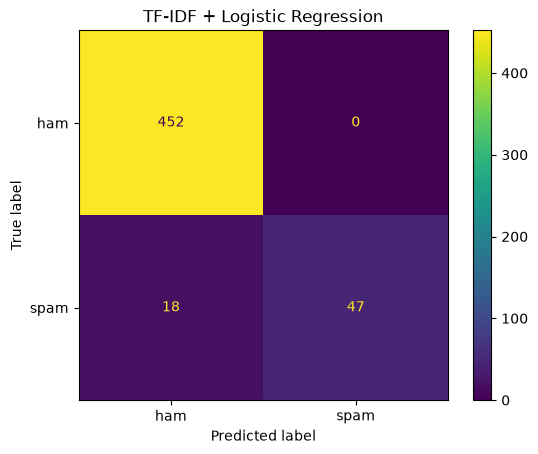

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.title("TF-IDF + Logistic Regression")
plt.show()

In [39]:
baseline_results = {
    "model": "TF-IDF + Logistic Regression",
    "accuracy": tfidf_accuracy,
    "precision": tfidf_precision,
    "recall": tfidf_recall,
    "f1": tfidf_f1
}

baseline_results

{'model': 'TF-IDF + Logistic Regression',
 'accuracy': 0.965183752417795,
 'precision': 1.0,
 'recall': 0.7230769230769231,
 'f1': 0.8392857142857143}

In [40]:
baseline_results["precision"]

1.0

In [55]:
from sklearn.metrics import f1_score

tfidf_macro_f1 = f1_score(
    y_test,
    test_pred,
    average="macro"
)

print("TF-IDF Macro-F1:", tfidf_macro_f1)

TF-IDF Macro-F1: 0.9098814688565231


In [56]:
new_result = pd.DataFrame([{
    "model": baseline_results['model'],
    "accuracy": baseline_results["accuracy"],
    "precision": baseline_results["precision"],
    "recall": baseline_results["recall"],
    "f1": baseline_results["f1"],
    "Macro-F1" : tfidf_macro_f1
}])
new_result


,model,accuracy,precision,recall,f1,Macro-F1
0,TF-IDF + Logistic Regression,0.965184,1.0,0.723077,0.839286,0.909881


In [57]:

print("TF-IDF F1:", tfidf_f1)

print(classification_report(
    y_test,
    test_pred,
    target_names=["ham", "spam"]
))

TF-IDF F1: 0.8392857142857143
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       452
        spam       1.00      0.72      0.84        65

    accuracy                           0.97       517
   macro avg       0.98      0.86      0.91       517
weighted avg       0.97      0.97      0.96       517



In [58]:
pd.DataFrame([baseline_results]).to_csv(
    "baseline_results_tfidf.csv",
    index=False
)